In [31]:
# ============================================================
# Global Temperature Data Cleaning
# Step 1: Load and Standardize Dates
# ============================================================

import pandas as pd
import re


# ============================================================
# 1. LOAD THE DATA
# ============================================================

# Read all columns as text because the original file contains
# mixed formats and intentionally corrupted values.

df = pd.read_csv(
    "global_temp_dirty_v2.csv",
    dtype=str
)

print("Original number of rows:", len(df))


Original number of rows: 1711


In [32]:
# ============================================================
# 2. CLEAN COLUMN NAMES AND WHITESPACE
# ============================================================

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Remove extra spaces from values in every column
for col in df.columns:
    df[col] = df[col].str.strip()

print("\nColumn names:")
print(df.columns.tolist())



Column names:
['Date', 'Temperature_Anomaly', 'Source/Notes']


In [33]:
# ============================================================
# 3. MONTH NAME LOOKUP
# ============================================================

# Dictionary used to convert month names into month numbers.

MONTHS = {
    "jan": 1,
    "january": 1,

    "feb": 2,
    "february": 2,

    "mar": 3,
    "march": 3,

    "apr": 4,
    "april": 4,

    "may": 5,

    "jun": 6,
    "june": 6,

    "jul": 7,
    "july": 7,

    "aug": 8,
    "august": 8,

    "sep": 9,
    "september": 9,

    "oct": 10,
    "october": 10,

    "nov": 11,
    "november": 11,

    "dec": 12,
    "december": 12
}


In [34]:
# ============================================================
# 4. HANDLE TWO-DIGIT YEARS
# ============================================================

# The assignment specifies:
#
# 26-99 -> 1926-1999
# 00-25 -> 2000-2025
#
# We cannot use pandas' default interpretation because it can
# interpret values such as "43" as 2043.

def parse_year(year):

    year = int(year)

    if year < 100:

        if 26 <= year <= 99:
            return 1900 + year

        return 2000 + year

    return year


# ============================================================
# 5. CREATE A DATETIME FROM YEAR AND MONTH
# ============================================================

def make_date(year, month):

    try:

        year = int(year)
        month = int(month)

        # Check that month is valid
        if not 1 <= month <= 12:
            return pd.NaT

        # The assignment says the day carries no information,
        # so every date is stored as the first day of the month.

        return pd.Timestamp(
            year=year,
            month=month,
            day=1
        )

    except (ValueError, TypeError):

        return pd.NaT

In [35]:
# ============================================================
# 6. PARSE DIFFERENT DATE FORMATS
# ============================================================

def parse_date(value):

    # --------------------------------------------------------
    # Check for missing values
    # --------------------------------------------------------

    if pd.isna(value):
        return pd.NaT

    value = str(value).strip()

    if value == "":
        return pd.NaT


    # --------------------------------------------------------
    # Format 1: YYYYMM
    #
    # Examples:
    # 188001
    # 188202
    # 188304
    # --------------------------------------------------------

    match = re.fullmatch(
        r"(\d{4})(\d{2})",
        value
    )

    if match:

        year = match.group(1)
        month = match.group(2)

        return make_date(year, month)


    # --------------------------------------------------------
    # Format 2: YYYY/MM
    #
    # Examples:
    # 1880/03
    # 1881/01
    # 1884/10
    # --------------------------------------------------------

    match = re.fullmatch(
        r"(\d{4})/(\d{1,2})",
        value
    )

    if match:

        year = match.group(1)
        month = match.group(2)

        return make_date(year, month)


    # --------------------------------------------------------
    # Format 3: YYYY.MM
    #
    # Examples:
    # 1880.04
    # 1884.03
    # 1890.03
    # --------------------------------------------------------

    match = re.fullmatch(
        r"(\d{4})\.(\d{1,2})",
        value
    )

    if match:

        year = match.group(1)
        month = match.group(2)

        return make_date(year, month)


    # --------------------------------------------------------
    # Format 4: YYYY-MM
    #
    # Example:
    # 1880-05
    # --------------------------------------------------------

    match = re.fullmatch(
        r"(\d{4})-(\d{1,2})",
        value
    )

    if match:

        year = match.group(1)
        month = match.group(2)

        return make_date(year, month)


    # --------------------------------------------------------
    # Format 5: YYYY-MM-DD
    #
    # Examples:
    # 1880-05-01
    # 1881-06-01
    # 1890-10-01
    #
    # The day is ignored.
    # --------------------------------------------------------

    match = re.fullmatch(
        r"(\d{4})-(\d{1,2})-(\d{1,2})",
        value
    )

    if match:

        year = match.group(1)
        month = match.group(2)

        return make_date(year, month)


    # --------------------------------------------------------
    # Format 6: MM/YYYY
    #
    # Examples:
    # 11/1880
    # 04/1881
    # 07/1882
    # --------------------------------------------------------

    match = re.fullmatch(
        r"(\d{1,2})/(\d{4})",
        value
    )

    if match:

        month = match.group(1)
        year = match.group(2)

        return make_date(year, month)


    # --------------------------------------------------------
    # Format 7: MM-YYYY
    #
    # Examples:
    # 05-1881
    # 12-1883
    # 09-1884
    # --------------------------------------------------------

    match = re.fullmatch(
        r"(\d{1,2})-(\d{4})",
        value
    )

    if match:

        month = match.group(1)
        year = match.group(2)

        return make_date(year, month)


    # --------------------------------------------------------
    # Format 8: Month YYYY
    #
    # Examples:
    # June 1880
    # July 1881
    # November 1898
    # --------------------------------------------------------

    match = re.fullmatch(
        r"([A-Za-z]+)\s+(\d{4})",
        value
    )

    if match:

        month_name = match.group(1).lower()
        year = match.group(2)

        if month_name in MONTHS:

            month = MONTHS[month_name]

            return make_date(year, month)


    # --------------------------------------------------------
    # Format 9: Month-YYYY
    #
    # Examples:
    # Feb-1880
    # Aug-1880
    # January-1882
    # --------------------------------------------------------

    match = re.fullmatch(
        r"([A-Za-z]+)-(\d{4})",
        value
    )

    if match:

        month_name = match.group(1).lower()
        year = match.group(2)

        if month_name in MONTHS:

            month = MONTHS[month_name]

            return make_date(year, month)


    # --------------------------------------------------------
    # Format 10: YYYY Month
    #
    # Examples:
    # 1881 Sep
    # 1881 Dec
    # 1888 Oct
    # --------------------------------------------------------

    match = re.fullmatch(
        r"(\d{4})\s+([A-Za-z]+)",
        value
    )

    if match:

        year = match.group(1)
        month_name = match.group(2).lower()

        if month_name in MONTHS:

            month = MONTHS[month_name]

            return make_date(year, month)


    # --------------------------------------------------------
    # Format 11: YYYY-Month
    #
    # Example:
    # 1888-June
    # --------------------------------------------------------

    match = re.fullmatch(
        r"(\d{4})-([A-Za-z]+)",
        value
    )

    if match:

        year = match.group(1)
        month_name = match.group(2).lower()

        if month_name in MONTHS:

            month = MONTHS[month_name]

            return make_date(year, month)


    # --------------------------------------------------------
    # Format 12: Month-YY
    #
    # Examples:
    # Feb-27
    # Jan-43
    # Feb-47
    #
    # Two-digit year is handled using the assignment rule.
    # --------------------------------------------------------

    match = re.fullmatch(
        r"([A-Za-z]+)-(\d{2})",
        value
    )

    if match:

        month_name = match.group(1).lower()
        year = parse_year(match.group(2))

        if month_name in MONTHS:

            month = MONTHS[month_name]

            return make_date(year, month)


    # --------------------------------------------------------
    # Format 13: Month YY
    #
    # Examples:
    # Jan 43
    # Feb 27
    # --------------------------------------------------------

    match = re.fullmatch(
        r"([A-Za-z]+)\s+(\d{2})",
        value
    )

    if match:

        month_name = match.group(1).lower()
        year = parse_year(match.group(2))

        if month_name in MONTHS:

            month = MONTHS[month_name]

            return make_date(year, month)


    # --------------------------------------------------------
    # Format 14: M/D/YY
    #
    # Examples:
    # 7/1/07
    # 5/1/26
    # 3/1/27
    #
    # Day is ignored.
    # --------------------------------------------------------

    match = re.fullmatch(
        r"(\d{1,2})/(\d{1,2})/(\d{2})",
        value
    )

    if match:

        month = int(match.group(1))
        year = parse_year(match.group(3))

        if 1 <= month <= 12:

            return make_date(year, month)


    # --------------------------------------------------------
    # If no format matched
    # --------------------------------------------------------

    return pd.NaT

In [36]:
# ============================================================
# 7. PARSE THE ORIGINAL DATE COLUMN
# ============================================================

df["parsed_date"] = df["Date"].apply(parse_date)


# ============================================================
# 8. PARSE TEMPERATURE VALUES
# ============================================================

def parse_anomaly(value):

    if pd.isna(value):
        return pd.NA

    value = str(value).strip()

    # Values that represent missing data
    missing_tokens = {
        "",
        ".",
        "--",
        "nan",
        "null",
        "na",
        "n/a",
        "#n/a",
        "missing"
    }

    if value.lower() in missing_tokens:
        return pd.NA

    # Remove Celsius unit
    value = value.replace("°C", "")

    # Convert comma decimal to standard decimal
    # Example: -0,199 -> -0.199
    value = value.replace(",", ".")

    try:

        return float(value)

    except ValueError:

        return pd.NA


df["parsed_anomaly"] = df[
    "Temperature_Anomaly"
].apply(parse_anomaly)

In [37]:
# ============================================================
# 9. DETECT SWAPPED DATE AND TEMPERATURE FIELDS
# ============================================================

# If the normal Date column cannot be parsed as a date,
# check whether the Temperature_Anomaly column contains
# a valid date instead.

df["swapped_date"] = df[
    "Temperature_Anomaly"
].apply(parse_date)


# Similarly, check whether the Date column contains a valid
# temperature value.

df["swapped_anomaly"] = df[
    "Date"
].apply(parse_anomaly)


# A row is considered swapped when:
#
# 1. The original Date is not a valid date
# 2. The Temperature column contains a valid date
# 3. The Date column contains a valid anomaly

swap_mask = (
    df["parsed_date"].isna()
    &
    df["swapped_date"].notna()
    &
    df["swapped_anomaly"].notna()
)

In [46]:
# ============================================================
# 10. RECORD SWAPPED ROWS BEFORE REPAIRING THEM
# ============================================================

swapped_rows = df.loc[
    swap_mask,
    [
        "Date",
        "Temperature_Anomaly",
        "swapped_date",
        "swapped_anomaly"
    ]
].copy()


print("\nNumber of swapped rows detected:", len(swapped_rows))


# ============================================================
# 11. REPAIR SWAPPED ROWS
# ============================================================

missing_temp_swap_mask = (
    df["parsed_date"].isna()
    &
    df["swapped_date"].notna()
    &
    df["Date"].isna()
)

print(
    "Rows with date stored in temperature column:",
    missing_temp_swap_mask.sum()
)

# Repair the date
df.loc[
    missing_temp_swap_mask,
    "parsed_date"
] = df.loc[
    missing_temp_swap_mask,
    "swapped_date"
]

# Temperature remains missing
df.loc[
    missing_temp_swap_mask,
    "parsed_anomaly"
] = pd.NA


# ============================================================
# 12. IDENTIFY NON-DATA / UNPARSED ROWS
# ============================================================

# At this point, any row that still has no parsed date
# is either a blank row or a non-data line.
#
# We record these rows before removing them.

unparsed_mask = df["parsed_date"].isna()

unparsed_rows = df.loc[
    unparsed_mask,
    [
        "Date",
        "Temperature_Anomaly",
        "Source/Notes"
    ]
].copy()


print("\n")
print("=" * 70)
print("TRUE NON-DATA / UNPARSED ROWS")
print("=" * 70)

print(
    unparsed_rows.to_string(index=False)
)

# ============================================================
# 13. IDENTIFY DATASET DATE RANGE PROBLEMS
# ============================================================

out_of_range_mask = (
    df["parsed_date"].notna()
    &
    (
        (df["parsed_date"] < pd.Timestamp("1880-01-01"))
        |
        (df["parsed_date"] > pd.Timestamp("2025-12-01"))
    )
)

out_of_range_rows = df.loc[
    out_of_range_mask,
    [
        "Date",
        "Temperature_Anomaly",
        "parsed_date"
    ]
].copy()


# ============================================================
# 14. IDENTIFY DATE PATTERNS
# ============================================================

def identify_pattern(value):

    if pd.isna(value):
        return "MISSING"

    value = str(value).strip()

    if value == "":
        return "MISSING"

    if re.fullmatch(r"\d{6}", value):
        return "YYYYMM"

    if re.fullmatch(r"\d{4}/\d{1,2}", value):
        return "YYYY/MM"

    if re.fullmatch(r"\d{4}\.\d{1,2}", value):
        return "YYYY.MM"

    if re.fullmatch(r"\d{4}-\d{1,2}", value):
        return "YYYY-MM"

    if re.fullmatch(r"\d{4}-\d{1,2}-\d{1,2}", value):
        return "YYYY-MM-DD"

    if re.fullmatch(r"\d{1,2}/\d{4}", value):
        return "MM/YYYY"

    if re.fullmatch(r"\d{1,2}-\d{4}", value):
        return "MM-YYYY"

    if re.fullmatch(r"[A-Za-z]+\s+\d{4}", value):
        return "Month YYYY"

    if re.fullmatch(r"[A-Za-z]+-\d{4}", value):
        return "Month-YYYY"

    if re.fullmatch(r"\d{4}\s+[A-Za-z]+", value):
        return "YYYY Month"

    if re.fullmatch(r"\d{4}-[A-Za-z]+", value):
        return "YYYY-Month"

    if re.fullmatch(r"[A-Za-z]+-\d{2}", value):
        return "Month-YY"

    if re.fullmatch(r"[A-Za-z]+\s+\d{2}", value):
        return "Month YY"

    if re.fullmatch(r"\d{1,2}/\d{1,2}/\d{2}", value):
        return "M/D/YY"

    return "UNKNOWN"


df["date_pattern"] = df["Date"].apply(
    identify_pattern
)



Number of swapped rows detected: 31
Rows with date stored in temperature column: 0


TRUE NON-DATA / UNPARSED ROWS
                                                                                                         Date Temperature_Anomaly Source/Notes
                                                                                                          NaN                 NaN          NaN
                                                                                                  END OF DATA                 NaN          NaN
                                                                                                          NaN                 NaN          NaN
Source: SIMULATED teaching dataset (not official NOAA/NASA/HadCRUT values). Anomaly baseline: 1901-2000 mean.                 NaN          NaN


In [47]:
# ============================================================
# 15. DISPLAY DATE CLEANING RESULTS
# ============================================================

print("\n")
print("=" * 60)
print("DATE PARSING SUMMARY")
print("=" * 60)

print("Original rows:", len(df))

print(
    "Successfully parsed dates:",
    df["parsed_date"].notna().sum()
)

print(
    "Swapped rows repaired:",
    len(swapped_rows)
)

print(
    "Unparsed/non-data rows:",
    len(unparsed_rows)
)

print(
    "Out-of-range dates:",
    len(out_of_range_rows)
)





DATE PARSING SUMMARY
Original rows: 1711
Successfully parsed dates: 1707
Swapped rows repaired: 31
Unparsed/non-data rows: 4
Out-of-range dates: 0


In [48]:
# ============================================================
# 16. SHOW SWAPPED ROWS
# ============================================================

print("\n")
print("=" * 60)
print("SWAPPED ROWS DETECTED")
print("=" * 60)

if len(swapped_rows) > 0:

    print(
        swapped_rows.to_string(index=False)
    )

else:

    print("No swapped rows detected.")



SWAPPED ROWS DETECTED
  Date Temperature_Anomaly swapped_date swapped_anomaly
-0.533            Jul 1893   1893-07-01          -0.533
-0.698          1898-06-01   1898-06-01          -0.698
-0.593             1901/10   1901-10-01          -0.593
-0.391             1903/09   1903-09-01          -0.391
-0.489             1906/06   1906-06-01          -0.489
-0.479            Jul-1907   1907-07-01          -0.479
 -0.55            1908 Sep   1908-09-01           -0.55
-0.646            Nov-1911   1911-11-01          -0.646
-0.589             1916/11   1916-11-01          -0.589
-0.183              Feb-36   1936-02-01          -0.183
-0.066              Jan-43   1943-01-01          -0.066
-0.062              Feb-47   1947-02-01          -0.062
 0.064             1953/08   1953-08-01           0.064
  0.09             1961.03   1961-03-01            0.09
 0.248              Jan-63   1963-01-01           0.248
 0.104              Mar-63   1963-03-01           0.104
 0.116              Aug-

In [49]:
# ============================================================
# 17. SHOW UNPARSED ROWS
# ============================================================

print("\n")
print("=" * 60)
print("UNPARSED / NON-DATA ROWS")
print("=" * 60)

if len(unparsed_rows) > 0:

    print(
        unparsed_rows.to_string(index=False)
    )

else:

    print("No unparsed rows.")



UNPARSED / NON-DATA ROWS
                                                                                                         Date Temperature_Anomaly Source/Notes
                                                                                                          NaN                 NaN          NaN
                                                                                                  END OF DATA                 NaN          NaN
                                                                                                          NaN                 NaN          NaN
Source: SIMULATED teaching dataset (not official NOAA/NASA/HadCRUT values). Anomaly baseline: 1901-2000 mean.                 NaN          NaN


In [42]:
# ============================================================
# 18. SHOW OUT-OF-RANGE DATES
# ============================================================

print("\n")
print("=" * 60)
print("OUT-OF-RANGE DATES")
print("=" * 60)

if len(out_of_range_rows) > 0:

    print(
        out_of_range_rows.to_string(index=False)
    )

else:

    print("No out-of-range dates.")



OUT-OF-RANGE DATES
No out-of-range dates.


In [43]:
# ============================================================
# 19. SHOW DATE PATTERN COUNTS
# ============================================================

print("\n")
print("=" * 60)
print("DATE PATTERNS")
print("=" * 60)

print(
    df["date_pattern"].value_counts()
)




DATE PATTERNS
date_pattern
Month-YY      576
YYYY/MM       376
Month-YYYY    247
M/D/YY        181
YYYY.MM        97
YYYY Month     57
YYYY-MM-DD     41
YYYYMM         39
UNKNOWN        33
Month YYYY     29
MM/YYYY        19
MM-YYYY        13
MISSING         3
Name: count, dtype: int64


In [44]:
# ============================================================
# 20. CHECK FINAL PARSED DATES
# ============================================================

print("\n")
print("=" * 60)
print("SAMPLE CLEANED DATES")
print("=" * 60)

print(
    df[
        [
            "Date",
            "Temperature_Anomaly",
            "parsed_date",
            "parsed_anomaly"
        ]
    ].head(20).to_string(index=False)
)



SAMPLE CLEANED DATES
      Date Temperature_Anomaly parsed_date parsed_anomaly
    188001               -0.73  1880-01-01          -0.73
  Feb-1880              -0.752  1880-02-01         -0.752
  Feb-1880              -0.752  1880-02-01         -0.752
   1880/03              -0.670  1880-03-01          -0.67
   1880.04              -0.593  1880-04-01         -0.593
1880-05-01              -0.739  1880-05-01         -0.739
  Jun 1880              -0.756  1880-06-01         -0.756
1880-07-01                -500  1880-07-01         -500.0
  Aug-1880              -0.724  1880-08-01         -0.724
  Sep 1880              -0.841  1880-09-01         -0.841
   1880/10              -0,766  1880-10-01         -0.766
   11/1880              -0,839  1880-11-01         -0.839
   1880/12            -0.820°C  1880-12-01          -0.82
   1881/01               -0.74  1881-01-01          -0.74
  Mar-1881              -0.849  1881-03-01         -0.849
   04/1881              -0.749  1881-04-01       

In [51]:
# ============================================================
# 21. CREATE CLEANING LOG INFORMATION
# ============================================================

cleaning_log = []

# ------------------------------------------------------------
# Swapped rows that were successfully repaired
# ------------------------------------------------------------

for _, row in swapped_rows.iterrows():

    cleaning_log.append(
        f"SWAPPED ROW REPAIRED: "
        f"Date='{row['Date']}', "
        f"Temperature='{row['Temperature_Anomaly']}' "
        f"-> date='{row['swapped_date']}', "
        f"anomaly='{row['swapped_anomaly']}'"
    )


# ------------------------------------------------------------
# Rows where the date was stored in the temperature column
# but the temperature itself was missing
# ------------------------------------------------------------

for _, row in df.loc[
    missing_temp_swap_mask
].iterrows():

    cleaning_log.append(
        f"MISSING TEMPERATURE: "
        f"date='{row['swapped_date']}', "
        f"original Date='{row['Date']}', "
        f"original Temperature='{row['Temperature_Anomaly']}'"
    )


# ------------------------------------------------------------
# True non-data / unparsed rows
# ------------------------------------------------------------

for _, row in unparsed_rows.iterrows():

    cleaning_log.append(
        f"NON-DATA / UNPARSED ROW: "
        f"Date='{row['Date']}', "
        f"Temperature='{row['Temperature_Anomaly']}', "
        f"Source/Notes='{row['Source/Notes']}'"
    )


# ------------------------------------------------------------
# Summary counts
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("CLEANING LOG SUMMARY")
print("=" * 70)

print("Original rows:", len(df))

print(
    "Swapped rows repaired:",
    len(swapped_rows)
)

print(
    "Missing-temperature rows:",
    missing_temp_swap_mask.sum()
)

print(
    "Non-data/unparsed rows:",
    len(unparsed_rows)
)

print(
    "Total cleaning-log entries:",
    len(cleaning_log)
)



CLEANING LOG SUMMARY
Original rows: 1711
Swapped rows repaired: 31
Missing-temperature rows: 0
Non-data/unparsed rows: 4
Total cleaning-log entries: 35


In [52]:
# ============================================================
# 22. REMOVE TRUE NON-DATA ROWS
# ============================================================

df = df.loc[~unparsed_mask].copy()

print(
    "\nRows after removing non-data rows:",
    len(df)
)

print(
    "Remaining unparsed dates:",
    df["parsed_date"].isna().sum()
)


Rows after removing non-data rows: 1707
Remaining unparsed dates: 0


In [53]:
# ============================================================
#  CHECK FOR DUPLICATE MONTHS
# ============================================================

# Find rows where the cleaned date occurs more than once.

duplicate_mask = df["parsed_date"].duplicated(
    keep=False
)

duplicate_rows = df.loc[
    duplicate_mask,
    [
        "Date",
        "Temperature_Anomaly",
        "parsed_date",
        "parsed_anomaly"
    ]
].sort_values("parsed_date")


print("\n")
print("=" * 70)
print("DUPLICATE MONTHS")
print("=" * 70)

print(
    duplicate_rows.to_string(index=False)
)

print(
    "\nNumber of duplicate rows:",
    duplicate_rows.shape[0]
)

print(
    "Number of duplicate months:",
    duplicate_rows["parsed_date"].nunique()
)



DUPLICATE MONTHS
      Date Temperature_Anomaly parsed_date parsed_anomaly
  Feb-1880              -0.752  1880-02-01         -0.752
  Feb-1880              -0.752  1880-02-01         -0.752
  May-1883              -0.630  1883-05-01          -0.63
  May 1883              -0.630  1883-05-01          -0.63
1899-03-01              -0.581  1899-03-01         -0.581
March 1899              -0.581  1899-03-01         -0.581
  Mar-1900              -0.472  1900-03-01         -0.472
  Mar-1900              -0.472  1900-03-01         -0.472
    -0.479            Jul-1907  1907-07-01         -0.479
  Jul-1907              -0.479  1907-07-01         -0.479
  Dec-1908              -0,601  1908-12-01         -0.601
  Dec-1908              -0,601  1908-12-01         -0.601
  Jun-1915              -0.261  1915-06-01         -0.261
   1915.06              -0.261  1915-06-01         -0.261
    4/1/33              -0.261  1933-04-01         -0.261
    Apr-33              -0.261  1933-04-01         -0

In [54]:
# ============================================================
#  REMOVE DUPLICATE MONTHS
# ============================================================

rows_before_dedup = len(df)

df = df.drop_duplicates(
    subset="parsed_date",
    keep="first"
).copy()

duplicates_removed = rows_before_dedup - len(df)

print("\n")
print("=" * 70)
print("DEDUPLICATION")
print("=" * 70)

print("Rows before deduplication:", rows_before_dedup)
print("Rows after deduplication:", len(df))
print("Duplicate rows removed:", duplicates_removed)



DEDUPLICATION
Rows before deduplication: 1707
Rows after deduplication: 1687
Duplicate rows removed: 20


In [55]:
# ============================================================
#  SORT CHRONOLOGICALLY
# ============================================================

df = (
    df
    .sort_values("parsed_date")
    .reset_index(drop=True)
)

print("\n")
print("=" * 70)
print("CHRONOLOGICALLY SORTED DATA")
print("=" * 70)

print(
    df[
        ["parsed_date", "parsed_anomaly"]
    ].head(10).to_string(index=False)
)



CHRONOLOGICALLY SORTED DATA
parsed_date parsed_anomaly
 1880-01-01          -0.73
 1880-02-01         -0.752
 1880-03-01          -0.67
 1880-04-01         -0.593
 1880-05-01         -0.739
 1880-06-01         -0.756
 1880-07-01         -500.0
 1880-08-01         -0.724
 1880-09-01         -0.841
 1880-10-01         -0.766


In [56]:
# ============================================================
#  VERIFY ONE RECORD PER MONTH
# ============================================================

remaining_duplicates = df[
    df["parsed_date"].duplicated(keep=False)
]

print("\n")
print("=" * 70)
print("DUPLICATE VALIDATION")
print("=" * 70)

print(
    "Duplicate rows remaining:",
    len(remaining_duplicates)
)

print(
    "Unique months:",
    df["parsed_date"].nunique()
)



DUPLICATE VALIDATION
Duplicate rows remaining: 0
Unique months: 1687


In [57]:
print("\nFirst date:", df["parsed_date"].min())
print("Last date:", df["parsed_date"].max())
print("Current number of rows:", len(df))


First date: 1880-01-01 00:00:00
Last date: 2025-12-01 00:00:00
Current number of rows: 1687


In [58]:
# ============================================================
# IQR OUTLIER DETECTION
# ============================================================

# Use only non-missing temperature values
# for calculating the IQR.

valid_values = df["parsed_anomaly"].dropna()

print("\n")
print("=" * 70)
print("IQR OUTLIER DETECTION")
print("=" * 70)

print("Number of non-missing values:", len(valid_values))



IQR OUTLIER DETECTION
Number of non-missing values: 1625


In [59]:
# Calculate the first and third quartiles

Q1 = valid_values.quantile(0.25)
Q3 = valid_values.quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: -0.385
Q3: 0.49
IQR: 0.875


In [60]:
# Calculate the lower and upper IQR fences

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print("Lower fence:", lower_fence)
print("Upper fence:", upper_fence)

Lower fence: -1.6975
Upper fence: 1.8025


In [61]:
# ============================================================
#  INSPECT IQR OUTLIERS BEFORE REMOVING
# ============================================================

outlier_mask = (
    (df["parsed_anomaly"] < lower_fence)
    |
    (df["parsed_anomaly"] > upper_fence)
)

outliers = df.loc[
    outlier_mask,
    [
        "parsed_date",
        "parsed_anomaly"
    ]
].copy()

print("\n")
print("=" * 70)
print("DETECTED OUTLIERS")
print("=" * 70)

print(
    outliers.to_string(index=False)
)

print(
    "\nNumber of outliers:",
    len(outliers)
)



DETECTED OUTLIERS
parsed_date parsed_anomaly
 1880-07-01         -500.0
 1882-01-01          500.0
 1888-09-01          500.0
 1891-08-01          500.0
 1897-01-01          500.0
 1900-06-01          500.0
 1900-10-01          500.0
 1901-05-01          500.0
 1905-01-01         -999.0
 1905-09-01          500.0
 1908-05-01          500.0
 1909-09-01          500.0
 1910-03-01         -500.0
 1913-10-01         -500.0
 1917-10-01          999.0
 1920-12-01          500.0
 1921-08-01         -999.0
 1924-02-01         -999.0
 1926-11-01          500.0
 1927-01-01          999.0
 1930-04-01          500.0
 1930-10-01         -500.0
 1934-12-01          500.0
 1943-07-01          500.0
 1947-11-01          500.0
 1950-12-01          999.0
 1951-06-01          500.0
 1952-04-01          500.0
 1956-03-01         -999.0
 1958-11-01          500.0
 1961-07-01         -999.0
 1962-11-01         -500.0
 1966-02-01         -500.0
 1967-01-01          500.0
 1971-06-01          500.0
 1974-06

In [62]:
# ============================================================
#  CHECK SENSOR-MALFUNCTION CODES
# ============================================================

malfunction_codes = [-999, -500, 500, 999]

malfunction_rows = df[
    df["parsed_anomaly"].isin(malfunction_codes)
][
    [
        "parsed_date",
        "parsed_anomaly"
    ]
]

print("\n")
print("=" * 70)
print("SENSOR MALFUNCTION CODES")
print("=" * 70)

print(
    malfunction_rows.to_string(index=False)
)

print(
    "\nNumber of malfunction codes:",
    len(malfunction_rows)
)



SENSOR MALFUNCTION CODES
parsed_date parsed_anomaly
 1880-07-01         -500.0
 1882-01-01          500.0
 1888-09-01          500.0
 1891-08-01          500.0
 1897-01-01          500.0
 1900-06-01          500.0
 1900-10-01          500.0
 1901-05-01          500.0
 1905-01-01         -999.0
 1905-09-01          500.0
 1908-05-01          500.0
 1909-09-01          500.0
 1910-03-01         -500.0
 1913-10-01         -500.0
 1917-10-01          999.0
 1920-12-01          500.0
 1921-08-01         -999.0
 1924-02-01         -999.0
 1926-11-01          500.0
 1927-01-01          999.0
 1930-04-01          500.0
 1930-10-01         -500.0
 1934-12-01          500.0
 1943-07-01          500.0
 1947-11-01          500.0
 1950-12-01          999.0
 1951-06-01          500.0
 1952-04-01          500.0
 1956-03-01         -999.0
 1958-11-01          500.0
 1961-07-01         -999.0
 1962-11-01         -500.0
 1966-02-01         -500.0
 1967-01-01          500.0
 1971-06-01          500.0
 

In [64]:
import numpy as np

In [65]:
# ============================================================
#  REPLACE IQR OUTLIERS WITH NaN
# ============================================================

outliers_removed = outlier_mask.sum()

df.loc[
    outlier_mask,
    "parsed_anomaly"
] = np.nan

print(
    "\nIQR outliers replaced with NaN:",
    outliers_removed
)


IQR outliers replaced with NaN: 63


In [66]:
# ============================================================
#  VERIFY MALFUNCTION CODES WERE REMOVED
# ============================================================

remaining_codes = df[
    df["parsed_anomaly"].isin(malfunction_codes)
]

print("\n")
print("=" * 70)
print("MALFUNCTION CODE VALIDATION")
print("=" * 70)

print(
    "Remaining ±500 / ±999 codes:",
    len(remaining_codes)
)

print(
    remaining_codes[
        ["parsed_date", "parsed_anomaly"]
    ].to_string(index=False)
)



MALFUNCTION CODE VALIDATION
Remaining ±500 / ±999 codes: 0
Empty DataFrame
Columns: [parsed_date, parsed_anomaly]
Index: []


In [67]:
# ============================================================
#  PREPARE CLEAN MONTHLY DATA
# ============================================================

clean_df = df[
    ["parsed_date", "parsed_anomaly"]
].copy()

clean_df = clean_df.rename(
    columns={
        "parsed_date": "date",
        "parsed_anomaly": "anomaly_c"
    }
)

clean_df = clean_df.set_index("date")

clean_df = clean_df.sort_index()

print(clean_df.head())

           anomaly_c
date                
1880-01-01     -0.73
1880-02-01    -0.752
1880-03-01     -0.67
1880-04-01    -0.593
1880-05-01    -0.739


In [68]:
# ============================================================
#  CREATE COMPLETE MONTHLY GRID
# ============================================================

complete_index = pd.date_range(
    start="1880-01-01",
    end="2025-12-01",
    freq="MS"
)

print("Expected number of months:", len(complete_index))

Expected number of months: 1752


In [69]:
# ============================================================
#  REINDEX TO COMPLETE MONTHLY GRID
# ============================================================

before_reindex = len(clean_df)

clean_df = clean_df.reindex(complete_index)

clean_df.index.name = "date"

print("\n")
print("=" * 70)
print("MONTHLY GRID")
print("=" * 70)

print("Rows before reindex:", before_reindex)
print("Rows after reindex:", len(clean_df))



MONTHLY GRID
Rows before reindex: 1687
Rows after reindex: 1752


In [70]:
# ============================================================
#  COUNT MISSING MONTHS BEFORE INTERPOLATION
# ============================================================

missing_before = clean_df["anomaly_c"].isna().sum()

print(
    "Missing anomaly values before interpolation:",
    missing_before
)

Missing anomaly values before interpolation: 190


In [74]:
# ============================================================
#  CONVERT ANOMALY TO NUMERIC
# ============================================================

clean_df["anomaly_c"] = pd.to_numeric(
    clean_df["anomaly_c"],
    errors="coerce"
)

print("Anomaly dtype:", clean_df["anomaly_c"].dtype)


# ============================================================
# COUNT MISSING VALUES BEFORE INTERPOLATION
# ============================================================

missing_before = clean_df["anomaly_c"].isna().sum()

print(
    "Missing anomaly values before interpolation:",
    missing_before
)


# ============================================================
#  LINEAR INTERPOLATION
# ============================================================

clean_df["anomaly_c"] = clean_df["anomaly_c"].interpolate(
    method="time"
)


# ============================================================
# VERIFY INTERPOLATION
# ============================================================

missing_after = clean_df["anomaly_c"].isna().sum()

print("\n")
print("=" * 70)
print("INTERPOLATION VALIDATION")
print("=" * 70)

print("Missing before interpolation:", missing_before)
print("Missing after interpolation:", missing_after)

if missing_after == 0:
    print("PASS: All missing values were interpolated.")
else:
    print("WARNING: Some missing values remain.")
    print(
        clean_df[
            clean_df["anomaly_c"].isna()
        ]
    )

Anomaly dtype: float64
Missing anomaly values before interpolation: 0


INTERPOLATION VALIDATION
Missing before interpolation: 0
Missing after interpolation: 0
PASS: All missing values were interpolated.


In [75]:
# ============================================================
#  CALCULATE 1901-2000 BASELINE
# ============================================================

baseline_period = clean_df.loc[
    "1901-01-01":"2000-12-01",
    "anomaly_c"
]

mu_20 = baseline_period.mean()

print("\n")
print("=" * 70)
print("1901-2000 BASELINE")
print("=" * 70)

print("Number of months:", len(baseline_period))
print("mu_20:", mu_20)



1901-2000 BASELINE
Number of months: 1200
mu_20: 0.00015934560722624742


In [76]:
# ============================================================
#  CALCULATE FULL-SERIES MEAN AND STANDARD DEVIATION
# ============================================================

mu = clean_df["anomaly_c"].mean()

sigma = clean_df["anomaly_c"].std()

print("\n")
print("=" * 70)
print("FULL-SERIES NORMALIZATION")
print("=" * 70)

print("mu:", mu)
print("sigma:", sigma)



FULL-SERIES NORMALIZATION
mu: 0.0464339644397177
sigma: 0.5199316472555549


In [77]:
# ============================================================
#  CALCULATE BASELINE-ADJUSTED ANOMALY
# ============================================================

clean_df["d"] = (
    clean_df["anomaly_c"] - mu_20
)

print(clean_df.head())

            anomaly_c         d
date                           
1880-01-01     -0.730 -0.730159
1880-02-01     -0.752 -0.752159
1880-03-01     -0.670 -0.670159
1880-04-01     -0.593 -0.593159
1880-05-01     -0.739 -0.739159


In [78]:
# ============================================================
#  CALCULATE Z-SCORE
# ============================================================

clean_df["z"] = (
    clean_df["anomaly_c"] - mu
) / sigma

print(clean_df.head())

            anomaly_c         d         z
date                                     
1880-01-01     -0.730 -0.730159 -1.493339
1880-02-01     -0.752 -0.752159 -1.535652
1880-03-01     -0.670 -0.670159 -1.377939
1880-04-01     -0.593 -0.593159 -1.229842
1880-05-01     -0.739 -0.739159 -1.510649


In [79]:
# ============================================================
#  VALIDATE Z-SCORE
# ============================================================

print("\n")
print("=" * 70)
print("Z-SCORE VALIDATION")
print("=" * 70)

print(
    "Mean z:",
    clean_df["z"].mean()
)

print(
    "Std z:",
    clean_df["z"].std()
)

print(
    "Minimum z:",
    clean_df["z"].min()
)

print(
    "Maximum z:",
    clean_df["z"].max()
)



Z-SCORE VALIDATION
Mean z: -1.2977949511600003e-16
Std z: 0.9999999999999988
Minimum z: -2.0895707544913456
Maximum z: 2.476414048570932


In [80]:
# ============================================================
#  FINAL NORMALIZATION CHECK
# ============================================================

print("\n")
print("=" * 70)
print("NORMALIZATION CHECK")
print("=" * 70)

print("mu_20 =", mu_20)
print("mu    =", mu)
print("sigma =", sigma)

print(
    "\nMissing anomaly values:",
    clean_df["anomaly_c"].isna().sum()
)

print(
    "Missing d values:",
    clean_df["d"].isna().sum()
)

print(
    "Missing z values:",
    clean_df["z"].isna().sum()
)



NORMALIZATION CHECK
mu_20 = 0.00015934560722624742
mu    = 0.0464339644397177
sigma = 0.5199316472555549

Missing anomaly values: 0
Missing d values: 0
Missing z values: 0


In [81]:
# ============================================================
#  CALCULATE ANNUAL SUMMARY
# ============================================================

annual_df = (
    clean_df[
        ["anomaly_c", "z"]
    ]
    .resample("YS")
    .mean()
)

# Convert the datetime index into a year
annual_df.index = annual_df.index.year

annual_df.index.name = "year"

print("\n")
print("=" * 70)
print("ANNUAL SUMMARY")
print("=" * 70)

print(annual_df.head())



ANNUAL SUMMARY
      anomaly_c         z
year                     
1880  -0.747522 -1.527039
1881  -0.792356 -1.613270
1882  -0.757875 -1.546951
1883  -0.820500 -1.667400
1884  -0.917582 -1.854121


In [82]:
# ============================================================
#  VERIFY 12 MONTHS PER YEAR
# ============================================================

monthly_counts = (
    clean_df["anomaly_c"]
    .resample("YS")
    .count()
)

print("\n")
print("=" * 70)
print("MONTHS PER YEAR CHECK")
print("=" * 70)

print(
    "Minimum months in a year:",
    monthly_counts.min()
)

print(
    "Maximum months in a year:",
    monthly_counts.max()
)

print(
    "Years with fewer than 12 months:",
    (monthly_counts < 12).sum()
)



MONTHS PER YEAR CHECK
Minimum months in a year: 12
Maximum months in a year: 12
Years with fewer than 12 months: 0


In [83]:
# ============================================================
#  FIND FIVE WARMEST YEARS
# ============================================================

top5_years = (
    annual_df
    .sort_values(
        "anomaly_c",
        ascending=False
    )
    .head(5)
    .copy()
)

print("\n")
print("=" * 70)
print("FIVE WARMEST YEARS")
print("=" * 70)

print(top5_years)



FIVE WARMEST YEARS
      anomaly_c         z
year                     
2024   1.167872  2.156894
2023   1.153376  2.129014
2025   1.012637  1.858326
2016   0.981765  1.798950
2022   0.960496  1.758043


In [84]:
# ============================================================
#  ADD RANK
# ============================================================

top5_table = top5_years.reset_index()

top5_table.insert(
    0,
    "Rank",
    range(1, len(top5_table) + 1)
)

print("\n")
print("=" * 70)
print("TOP 5 TABLE")
print("=" * 70)

print(top5_table)



TOP 5 TABLE
   Rank  year  anomaly_c         z
0     1  2024   1.167872  2.156894
1     2  2023   1.153376  2.129014
2     3  2025   1.012637  1.858326
3     4  2016   0.981765  1.798950
4     5  2022   0.960496  1.758043


In [85]:
# ============================================================
#  PREPARE TOP-5 TABLE FOR REPORT
# ============================================================

top5_report = top5_table.rename(
    columns={
        "year": "Year",
        "anomaly_c": "Mean anomaly (°C)",
        "z": "Mean z"
    }
)

print(top5_report)

   Rank  Year  Mean anomaly (°C)    Mean z
0     1  2024           1.167872  2.156894
1     2  2023           1.153376  2.129014
2     3  2025           1.012637  1.858326
3     4  2016           0.981765  1.798950
4     5  2022           0.960496  1.758043


In [86]:
# ============================================================
#  VALIDATE ANNUAL Z-SCORES
# ============================================================

annual_z_check = (
    (
        annual_df["anomaly_c"] - mu
    ) / sigma
)

difference = (
    annual_df["z"] - annual_z_check
).abs().max()

print("\n")
print("=" * 70)
print("ANNUAL Z-SCORE VALIDATION")
print("=" * 70)

print(
    "Maximum difference:",
    difference
)



ANNUAL Z-SCORE VALIDATION
Maximum difference: 2.220446049250313e-16


In [87]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.collections import LineCollection
from matplotlib.colors import TwoSlopeNorm

In [88]:
# ============================================================
#  PREPARE LINE SEGMENTS FOR DUAL ENCODING
# ============================================================

dates = clean_df.index
values = clean_df["anomaly_c"].values
color_values = clean_df["d"].values

# Convert dates to matplotlib numerical dates
x_values = mdates.date2num(dates.to_pydatetime())

# Create points: (x, y)
points = np.array(
    [
        x_values,
        values
    ]
).T

# Create line segments between consecutive points
segments = np.concatenate(
    [
        points[:-1, None, :],
        points[1:, None, :]
    ],
    axis=1
)

print("Number of line segments:", len(segments))

Number of line segments: 1751


In [89]:
# ============================================================
#  CENTERED COLOR NORMALIZATION
# ============================================================

color_norm = TwoSlopeNorm(
    vcenter=0,
    vmin=color_values.min(),
    vmax=color_values.max()
)

print("Color minimum:", color_values.min())
print("Color center:", 0)
print("Color maximum:", color_values.max())

Color minimum: -1.0401593456072262
Color center: 0
Color maximum: 1.3338406543927739


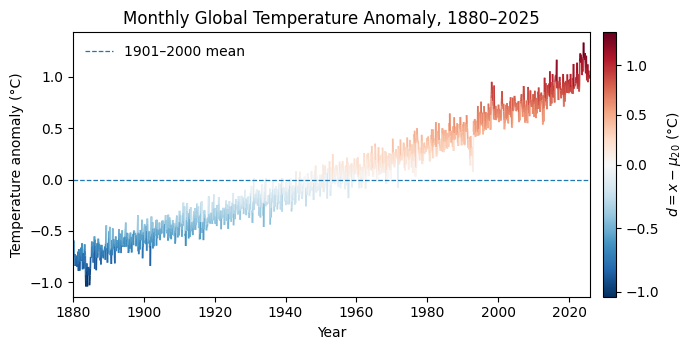

In [90]:
# ============================================================
# CREATE DUAL-ENCODED TEMPERATURE CHART
# ============================================================

fig, ax = plt.subplots(
    figsize=(7.16, 3.6)
)

# Create the colored line
line_collection = LineCollection(
    segments,
    cmap="RdBu_r",
    norm=color_norm,
    linewidth=1.2
)

# Assign color according to d
line_collection.set_array(color_values[:-1])

# Add line to plot
ax.add_collection(line_collection)


# Set plot limits
ax.set_xlim(
    x_values.min(),
    x_values.max()
)

ax.set_ylim(
    values.min() - 0.1,
    values.max() + 0.1
)


# Horizontal baseline
ax.axhline(
    y=mu_20,
    linestyle="--",
    linewidth=0.9,
    label="1901–2000 mean"
)


# Axis labels
ax.set_xlabel("Year")
ax.set_ylabel("Temperature anomaly (°C)")


# Title
ax.set_title(
    "Monthly Global Temperature Anomaly, 1880–2025"
)


# Date formatting
ax.xaxis.set_major_locator(
    mdates.YearLocator(20)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)


# Colorbar
colorbar = fig.colorbar(
    line_collection,
    ax=ax,
    pad=0.02
)

colorbar.set_label(
    r"$d = x-\mu_{20}$ (°C)"
)


# Legend
ax.legend(
    loc="upper left",
    frameon=False
)


# Layout
fig.tight_layout()

plt.show()

In [91]:
# ============================================================
#  SAVE FIGURE
# ============================================================

figure_filename = "temperature_dual_encoded.pdf"

fig.savefig(
    figure_filename,
    format="pdf",
    bbox_inches="tight"
)

print(
    "Figure saved as:",
    figure_filename
)

Figure saved as: temperature_dual_encoded.pdf


In [92]:
# ============================================================
#  BASELINE CHECK
# ============================================================

print("\n")
print("=" * 70)
print("CHART BASELINE CHECK")
print("=" * 70)

print("1901–2000 mean (mu_20):", mu_20)
print("Color center:", 0)

print(
    "Minimum d:",
    clean_df["d"].min()
)

print(
    "Maximum d:",
    clean_df["d"].max()
)



CHART BASELINE CHECK
1901–2000 mean (mu_20): 0.00015934560722624742
Color center: 0
Minimum d: -1.0401593456072262
Maximum d: 1.3338406543927739


In [93]:
# ============================================================
#  SAVE CLEANED MONTHLY DATA
# ============================================================

submission_df = clean_df[
    ["anomaly_c", "z"]
].copy()

# Convert datetime index to YYYY-MM
submission_df = submission_df.reset_index()

submission_df["date"] = submission_df["date"].dt.strftime("%Y-%m")

# Keep only the required columns
submission_df = submission_df[
    ["date", "anomaly_c", "z"]
]

submission_df.to_csv(
    "cleaned_monthly.csv",
    index=False
)

print("\n")
print("=" * 70)
print("CLEANED CSV SAVED")
print("=" * 70)

print("File: cleaned_monthly.csv")
print("Rows:", len(submission_df))
print("Columns:", list(submission_df.columns))

print("\nFirst 5 rows:")
print(submission_df.head())

print("\nLast 5 rows:")
print(submission_df.tail())



CLEANED CSV SAVED
File: cleaned_monthly.csv
Rows: 1752
Columns: ['date', 'anomaly_c', 'z']

First 5 rows:
      date  anomaly_c         z
0  1880-01     -0.730 -1.493339
1  1880-02     -0.752 -1.535652
2  1880-03     -0.670 -1.377939
3  1880-04     -0.593 -1.229842
4  1880-05     -0.739 -1.510649

Last 5 rows:
         date  anomaly_c         z
1747  2025-08   0.999000  1.832099
1748  2025-09   1.007639  1.848715
1749  2025-10   1.016000  1.864795
1750  2025-11   0.985000  1.805172
1751  2025-12   1.004000  1.841715


In [94]:
# ============================================================
#  CLEANING LOG COUNTS
# ============================================================

total_rows = len(df)

parsed_rows = df["parsed_date"].notna().sum()

unparsed_count = len(unparsed_rows)

duplicate_month_rows = (
    df["parsed_date"]
    .dropna()
    .duplicated(keep="first")
    .sum()
)

months_before_grid = (
    df["parsed_date"]
    .dropna()
    .nunique()
)

expected_months = 1752

missing_before_interpolation = missing_before

missing_after_interpolation = (
    clean_df["anomaly_c"].isna().sum()
)

print("Total rows:", total_rows)
print("Parsed rows:", parsed_rows)
print("Unparsed rows:", unparsed_count)
print("Duplicate month rows:", duplicate_month_rows)
print("Unique months before grid:", months_before_grid)
print("Expected months:", expected_months)
print("Missing before interpolation:", missing_before_interpolation)
print("Missing after interpolation:", missing_after_interpolation)
print("IQR outliers removed:", outliers_removed)

Total rows: 1687
Parsed rows: 1687
Unparsed rows: 4
Duplicate month rows: 0
Unique months before grid: 1687
Expected months: 1752
Missing before interpolation: 0
Missing after interpolation: 0
IQR outliers removed: 63


In [96]:
# ============================================================
#  WRITE CLEANING LOG
# ============================================================

with open("cleaning_log.txt", "w", encoding="utf-8") as f:

    f.write("=" * 70 + "\n")
    f.write("GLOBAL TEMPERATURE DATA CLEANING LOG\n")
    f.write("=" * 70 + "\n\n")

    f.write("Dataset: global_temp_dirty_v2.csv\n")
    f.write(
        "Note: Simulated teaching dataset; not official "
        "NOAA, NASA GISS, or HadCRUT data.\n\n"
    )

    # --------------------------------------------------------
    # DATE CLEANING
    # --------------------------------------------------------

    f.write("1. DATE STANDARDIZATION\n")
    f.write("-" * 70 + "\n")

    f.write(f"Total raw rows: {total_rows}\n")
    f.write(f"Successfully parsed dates: {parsed_rows}\n")
    f.write(f"Unparsed/non-data rows: {unparsed_count}\n")
    f.write(f"Out-of-range dates: {len(out_of_range_rows)}\n\n")

    # --------------------------------------------------------
    # DUPLICATES
    # --------------------------------------------------------

    f.write("2. DEDUPLICATION\n")
    f.write("-" * 70 + "\n")

    f.write(
        f"Duplicate month rows removed: "
        f"{duplicate_month_rows}\n"
    )

    f.write(
        f"Unique months before complete grid: "
        f"{months_before_grid}\n\n"
    )

    # --------------------------------------------------------
    # IQR
    # --------------------------------------------------------

    f.write("3. IQR OUTLIER REMOVAL\n")
    f.write("-" * 70 + "\n")

    f.write(f"Q1: {Q1:.10f}\n")
    f.write(f"Q3: {Q3:.10f}\n")
    f.write(f"IQR: {IQR:.10f}\n")
    f.write(f"Lower fence: {lower_fence:.10f}\n")
    f.write(f"Upper fence: {upper_fence:.10f}\n")
    f.write(f"Outliers removed: {outliers_removed}\n")

    f.write(
        f"Remaining sensor malfunction codes "
        f"(-999, -500, 500, 999): "
        f"{len(remaining_codes)}\n\n"
    )

    # --------------------------------------------------------
    # INTERPOLATION
    # --------------------------------------------------------

    f.write("4. MONTHLY GRID AND INTERPOLATION\n")
    f.write("-" * 70 + "\n")

    f.write(
        "Required range: January 1880 through December 2025\n"
    )

    f.write(
        f"Expected number of months: {expected_months}\n"
    )

    f.write(
        f"Missing values before interpolation: "
        f"{missing_before_interpolation}\n"
    )

    f.write(
        f"Missing values after interpolation: "
        f"{missing_after_interpolation}\n"
    )

    f.write(
        "Interpolation method: linear interpolation in time\n\n"
    )

    # --------------------------------------------------------
    # UNPARSED ROWS
    # --------------------------------------------------------

    f.write("5. UNPARSED / NON-DATA ROWS\n")
    f.write("-" * 70 + "\n")

    if len(unparsed_rows) == 0:

        f.write("No unparsed/non-data rows.\n")

    else:

        f.write(
            unparsed_rows.to_string(index=False)
        )

        f.write("\n")

    # --------------------------------------------------------
    # NORMALIZATION
    # --------------------------------------------------------

    f.write("\n6. NORMALIZATION\n")
    f.write("-" * 70 + "\n")

    f.write(f"mu_20 (1901-2000): {mu_20:.10f}\n")
    f.write(f"mu (1880-2025): {mu:.10f}\n")
    f.write(f"sigma (1880-2025): {sigma:.10f}\n")

print("cleaning_log.txt created.")

cleaning_log.txt created.
